# Model 1 — Rainfall only

Logistic regression on `precip_1h`, `precip_3h`, `precip_6h`, and `precip_24h`.
`ari_memory` is not used: in this CSV it copies `precip_24h`.

The shared split matches the other experiments. The spatial block split holds out whole 10 by 10 blocks so neighboring cells are not on both sides. The map places the 120 by 120 grid on longitude 68-97 E and latitude 8-37 N, then hides cells outside the India boundary, matching the Model 5 plotting cell. Row 0 is the southern edge.


In [1]:
import os
import sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from models.exp2_rainfall_only_rf import run_model_1

result = run_model_1()


[model_1_rainfall] WARNING: TARGET_COL='flood_label' is not in the processed dataset; using 'label'.


[model_1_rainfall] metrics saved to /private/tmp/flood-mapping/results/metrics/model_1_rainfall_metrics.json
[model_1_rainfall] map saved to /private/tmp/flood-mapping/results/maps/model_1_rainfall_susceptibility_map.png
  shared_split roc_auc 0.8727 accuracy 0.8500
    confusion_matrix [[347, 263], [169, 2101]]
  spatial_block_split roc_auc 0.8470 accuracy 0.8479
    confusion_matrix [[311, 262], [179, 2148]]


In [2]:
import json

for split_name in ("shared_split", "spatial_block_split"):
    split = result[split_name]
    print(split_name)
    print(json.dumps(split["metrics"], indent=2))
    print("confusion_matrix", split["confusion_matrix"]["matrix"])
    print()


shared_split
{
  "accuracy": 0.85,
  "precision": 0.8887478849407784,
  "recall": 0.9255506607929516,
  "f1_score": 0.9067760034527406,
  "roc_auc": 0.872721167039792
}
confusion_matrix [[347, 263], [169, 2101]]

spatial_block_split
{
  "accuracy": 0.8479310344827586,
  "precision": 0.891286307053942,
  "recall": 0.9230769230769231,
  "f1_score": 0.9069031032298923,
  "roc_auc": 0.8469758229330022
}
confusion_matrix [[311, 262], [179, 2148]]



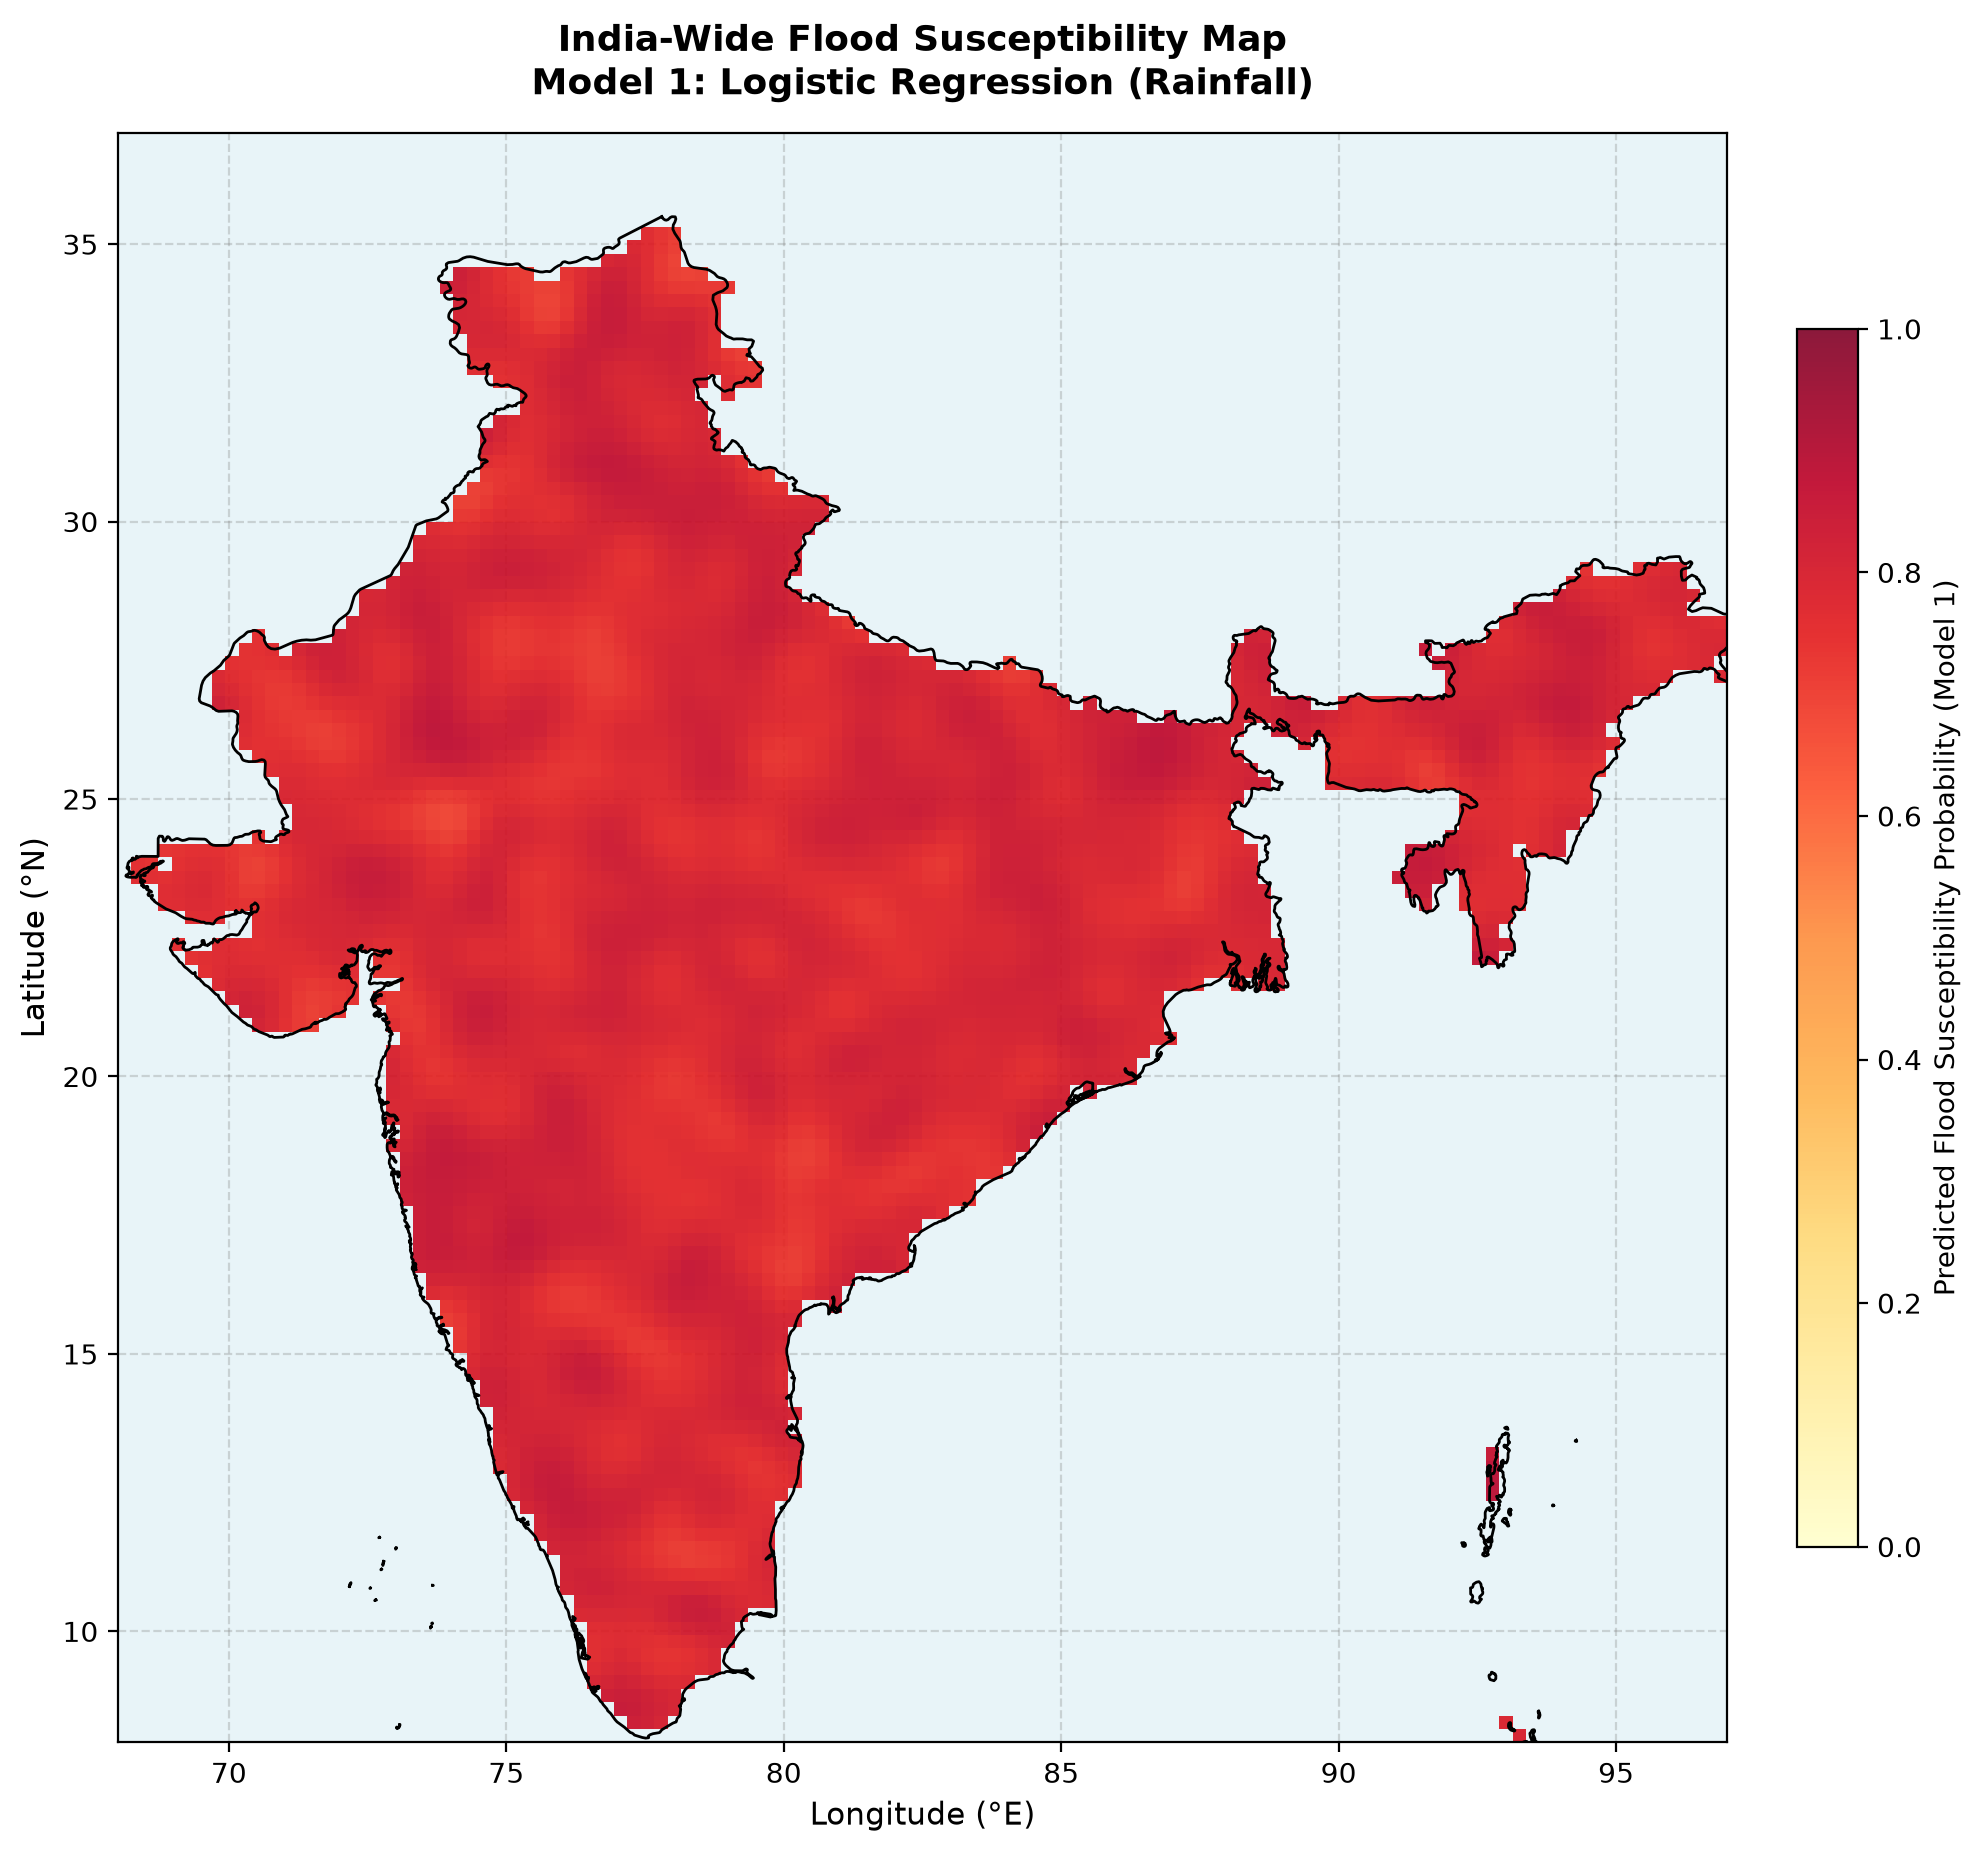

In [3]:
from IPython.display import Image, display

display(Image(filename=result["map"]))
